In [199]:
!pip install captum
!pip install shap

In [200]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from transformers import AdamW
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
from captum.attr import visualization as viz
from captum.attr import LayerConductance, LayerIntegratedGradients
from captum.attr import Saliency
import shap

In [201]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [202]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [203]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df1 = pd.read_csv('../data/letters_2021_processed.csv')
df1 = df1[['s1_s2', 'full_text', 'LETTER_GENDER']]
df1 = df1.rename(columns={'LETTER_GENDER':'label'})

In [204]:
df2 = pd.read_csv('../data/sentence_sets_trimmed_processed.csv')
df2 = df2[['s1_s2', 'full_text', 'applicant_gender']]
df2 = df2.rename(columns={'applicant_gender':'label'})

In [205]:
df = pd.concat([df1, df2], ignore_index=True)

In [206]:
gender_label_mapping = {
    'F':0,
    'female':0,
    'M':1,
    'male':1
}

In [207]:
df['label'] = df['label'].replace(gender_label_mapping)

<ipython-input-207-cc45885305bc>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace(gender_label_mapping)


# Create Training and Test Sets

In [208]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['s1_s2'], df['label'],
                                                                    random_state=0,
                                                                    test_size=0.3,
                                                                    stratify=df['label'])


val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels,
                                                                random_state=0,
                                                                test_size=0.5,
                                                                stratify=temp_labels)

In [209]:
bert = AutoModel.from_pretrained('distilbert-base-uncased')
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

In [210]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    padding='max_length',
    truncation=True
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    padding='max_length',
    truncation=True
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    padding='max_length',
    truncation=True
)

In [211]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

In [212]:
batch_size = 8
train_data = TensorDataset(train_seq, train_mask, train_y)
train_sampler = RandomSampler(train_data)
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

val_data = TensorDataset(val_seq, val_mask, val_y)
val_sampler = SequentialSampler(val_data)
val_dataloader = DataLoader(val_data, sampler = val_sampler, batch_size=batch_size)

In [213]:
# freeze weights, uncomment if you would like to unfreeze weights
for param in bert.parameters():
    param.requires_grad = False

# num_layers = len(bert.encoder.layer)

# for i in range(num_layers - 4, num_layers):
#     for param in bert.encoder.layer[i].parameters():
#         param.requires_grad = True

# Create Model

In [214]:
class BERT_Arch(nn.Module):

    def __init__(self, bert):

        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu =  nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(768,512)

        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(512,2)

        #softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    #define the forward pass
    def forward(self, sent_id, mask):

        #pass the inputs to the model
        distilbert_output = self.bert(sent_id, attention_mask=mask)

        hidden_state = distilbert_output[0]  # (bs, seq_len, dim)
        pooled_output = hidden_state[:, 0]

        x = self.fc1(pooled_output)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [215]:
model = BERT_Arch(bert)
model = model.to(device)

In [216]:
# optimizer = AdamW(model.parameters(), lr = 1e-4)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5, weight_decay=0.01)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(train_labels), y=train_labels)
weights= torch.tensor(class_weights,dtype=torch.float)
weights = weights.to(device)
cross_entropy  = nn.NLLLoss(weight=weights)
epochs = 10

In [217]:
# function to train the model
def train():

  model.train()

  total_loss, total_accuracy = 0, 0

  # empty list to save model predictions
  total_preds=[]
  total_labels=[]

  # iterate over batches
  for step,batch in enumerate(tqdm(train_dataloader, desc="Training", leave=True)):

    # # progress update after every 50 batches.
    # if step % 50 == 0 and not step == 0:
    #   print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(train_dataloader)))

    # push the batch to gpu
    batch = [r.to(device) for r in batch]

    sent_id, mask, labels = batch

    # clear previously calculated gradients
    model.zero_grad()

    # get model predictions for the current batch
    preds = model(sent_id, mask)

    # compute the loss between actual and predicted values
    loss = cross_entropy(preds, labels)

    # add on to the total loss
    total_loss = total_loss + loss.item()

    # backward pass to calculate the gradients
    loss.backward()

    # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

    # update parameters
    optimizer.step()

    # model predictions are stored on GPU. So, push it to CPU
    preds=preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    labels=labels.detach().cpu().numpy()

    # append labels
    total_labels.append(labels)

  # compute the training loss of the epoch
  avg_loss = total_loss / len(train_dataloader)

  # predictions are in the form of (no. of batches, size of batch, no. of classes).
  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Training Classification Report: ', classification_report(total_labels, epoch_preds))
  print('Training Confusion Matrix: ', confusion_matrix(total_labels, epoch_preds))

  #returns the loss and predictions
  return avg_loss, total_preds

In [218]:
# function for evaluating the model
def evaluate():

  print("\nEvaluating...")

  # deactivate dropout layers
  model.eval()

  total_loss, total_accuracy = 0, 0

  # empty list to save the model predictions
  total_preds = []
  total_labels = []

  # iterate over batches
  for step,batch in enumerate(val_dataloader):

    # # Progress update every 50 batches.
    # if step % 50 == 0 and not step == 0:

    #   # Calculate elapsed time in minutes.
    #   elapsed = format_time(time.time() - t0)

    #   # Report progress.
    #   print('  Batch {:>5,}  of  {:>5,}.'.format(step, len(val_dataloader)))

    # push the batch to gpu
    batch = [t.to(device) for t in batch]

    sent_id, mask, labels = batch

    # deactivate autograd
    with torch.no_grad():

      # model predictions
      preds = model(sent_id, mask)

      # compute the validation loss between actual and predicted values
      loss = cross_entropy(preds,labels)

      total_loss = total_loss + loss.item()

      preds = preds.detach().cpu().numpy()

      total_preds.append(preds)

      labels = labels.detach().cpu().numpy()

      total_labels.append(labels)

  # compute the validation loss of the epoch
  avg_loss = total_loss / len(val_dataloader)

  # reshape the predictions in form of (number of samples, no. of classes)
  total_preds  = np.concatenate(total_preds, axis=0)

  total_labels = np.concatenate(total_labels, axis=0)

  epoch_preds = np.argmax(total_preds, axis = 1)

  print('Validation Classification Report: ', classification_report(total_labels, epoch_preds))
  print('Validation Confusion Matrix: ', confusion_matrix(total_labels, epoch_preds))

  return avg_loss, total_preds

In [219]:
# set initial loss to infinite
best_valid_loss = float('inf')

# empty lists to store training and validation loss of each epoch
train_losses=[]
valid_losses=[]

#for each epoch
for epoch in tqdm(range(epochs), desc="Training"):

    print('\n Epoch {:} / {:}'.format(epoch + 1, epochs))

    #train model
    train_loss, _ = train()

    #evaluate model
    valid_loss, _ = evaluate()

    #save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        print('Model Saved!')
        torch.save(model, '../saved_models/saved_model.pt')

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f'\nTraining Loss: {train_loss:.3f}')
    print(f'Validation Loss: {valid_loss:.3f}')

Training:   0%|          | 0/10 [00:00<?, ?it/s]


 Epoch 1 / 10


Training:   0%|          | 0/787 [00:00<?, ?it/s]

Training Classification Report:                precision    recall  f1-score   support

           0       0.32      0.42      0.37      1950
           1       0.70      0.60      0.65      4340

    accuracy                           0.55      6290
   macro avg       0.51      0.51      0.51      6290
weighted avg       0.58      0.55      0.56      6290

Training Confusion Matrix:  [[ 822 1128]
 [1722 2618]]

Evaluating...
Validation Classification Report:                precision    recall  f1-score   support

           0       0.38      0.47      0.42       418
           1       0.73      0.65      0.69       930

    accuracy                           0.60      1348
   macro avg       0.56      0.56      0.55      1348
weighted avg       0.62      0.60      0.61      1348

Validation Confusion Matrix:  [[197 221]
 [324 606]]
Model Saved!

Training Loss: 0.694
Validation Loss: 0.687

 Epoch 2 / 10


Training:   0%|          | 0/787 [00:00<?, ?it/s]

...

Training Classification Report:                precision    recall  f1-score   support

           0       0.40      0.49      0.44      1950
           1       0.74      0.66      0.70      4340

    accuracy                           0.61      6290
   macro avg       0.57      0.58      0.57      6290
weighted avg       0.64      0.61      0.62      6290

Training Confusion Matrix:  [[ 965  985]
 [1465 2875]]

Evaluating...
Validation Classification Report:                precision    recall  f1-score   support

           0       0.46      0.30      0.36       418
           1       0.73      0.84      0.78       930

    accuracy                           0.67      1348
   macro avg       0.59      0.57      0.57      1348
weighted avg       0.64      0.67      0.65      1348

Validation Confusion Matrix:  [[126 292]
 [148 782]]
Model Saved!

Training Loss: 0.677
Validation Loss: 0.676

 Epoch 9 / 10


Training:   0%|          | 0/787 [00:00<?, ?it/s]

Training Classification Report:                precision    recall  f1-score   support

           0       0.40      0.47      0.43      1950
           1       0.74      0.68      0.71      4340

    accuracy                           0.62      6290
   macro avg       0.57      0.58      0.57      6290
weighted avg       0.64      0.62      0.62      6290

Training Confusion Matrix:  [[ 917 1033]
 [1377 2963]]

Evaluating...
Validation Classification Report:                precision    recall  f1-score   support

           0       0.39      0.72      0.51       418
           1       0.80      0.51      0.62       930

    accuracy                           0.57      1348
   macro avg       0.60      0.61      0.56      1348
weighted avg       0.67      0.57      0.59      1348

Validation Confusion Matrix:  [[299 119]
 [459 471]]

Training Loss: 0.677
Validation Loss: 0.679

 Epoch 10 / 10


Training:   0%|          | 0/787 [00:00<?, ?it/s]

Training Classification Report:                precision    recall  f1-score   support

           0       0.40      0.51      0.44      1950
           1       0.75      0.66      0.70      4340

    accuracy                           0.61      6290
   macro avg       0.57      0.58      0.57      6290
weighted avg       0.64      0.61      0.62      6290

Training Confusion Matrix:  [[ 985  965]
 [1492 2848]]

Evaluating...
Validation Classification Report:                precision    recall  f1-score   support

           0       0.47      0.24      0.32       418
           1       0.72      0.88      0.79       930

    accuracy                           0.68      1348
   macro avg       0.59      0.56      0.55      1348
weighted avg       0.64      0.68      0.64      1348

Validation Confusion Matrix:  [[100 318]
 [115 815]]
Model Saved!

Training Loss: 0.675
Validation Loss: 0.676


In [220]:
# model.load_state_dict(torch.load('saved_weights.pt'))

In [221]:
# def forward_func(input_ids, mask):
#     output = model(input_ids, mask=mask)
#     return output


In [222]:
# lig = LayerIntegratedGradients(forward_func, model.bert.embeddings)

In [223]:
# test_seq = test_seq.to(device)
# test_mask = test_mask.to(device)

In [224]:
# test_seq_obs = test_seq[:3]
# test_mask_obs = test_mask[:3]
# test_label_obs = test_y[:3]

In [225]:
# _, t = lig.attribute(inputs=test_seq_obs,
#               target=test_label_obs,
#               additional_forward_args=test_mask_obs)

# Shap values

In [226]:
def f(x):
    encoded_inputs = [tokenizer.encode_plus(v, padding="max_length", truncation=True, return_tensors="pt") for v in x]

    # Unpacking the encoded inputs into input_ids and attention_masks
    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    output = model(input_ids, attention_masks).detach().cpu().numpy()

    return output[:, 1]

In [227]:
explainer = shap.Explainer(f, tokenizer)

In [228]:
df

,s1_s2,full_text,label
0,it is my pleasure to write a letter of recomme...,it is my pleasure to write a letter of recomme...,0
1,i am pleased to highly recommend identifier ...,i am pleased to highly recommend identifier ...,0
2,i am writing this letter in support of identi...,i am writing this letter in support of identi...,0
3,identifier identifier recently completed a...,identifier identifier recently completed a...,0
4,it is my pleasure to recommend dr. identifier...,it is my pleasure to recommend dr. identifier...,0
...,...,...,...
8982,it is with pleasure that i recommend identifi...,it is with pleasure that i recommend identifi...,0
8983,we are very pleased to write this letter based...,we are very pleased to write this letter based...,0
8984,I am writing this letter of recommendation for...,I am writing this letter of recommendation for...,1
8985,it is my pleasure to write identifier suppor...,it is my pleasure to write identifier suppor...,1


In [229]:
#observations = df['s1_s2'][8970:]
observations = df['s1_s2'][:100]
shap_values = explainer(observations, fixed_context=1)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   4%|▍         | 4/100 [00:21<03:32,  2.21s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 5/100 [00:26<05:40,  3.58s/it]

...

PartitionExplainer explainer:  99%|█████████▉| 99/100 [14:15<00:07,  7.91s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 100/100 [14:24<00:00,  8.21s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 101it [14:33,  8.82s/it]


In [230]:
shap.plots.text(shap_values[68])

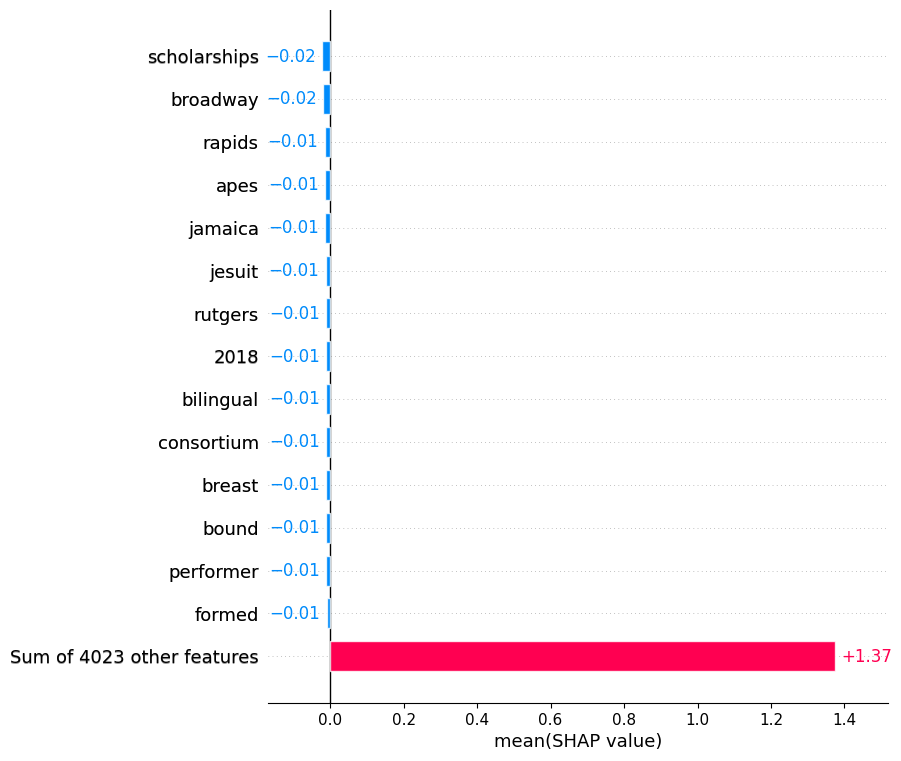

In [236]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=15)

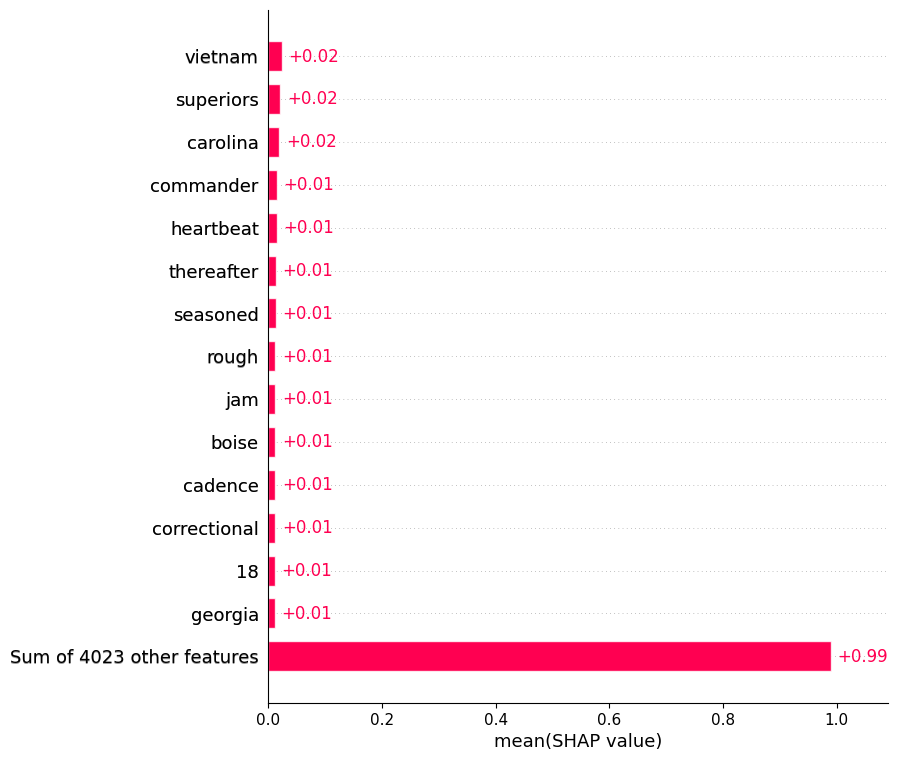

In [237]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=15)

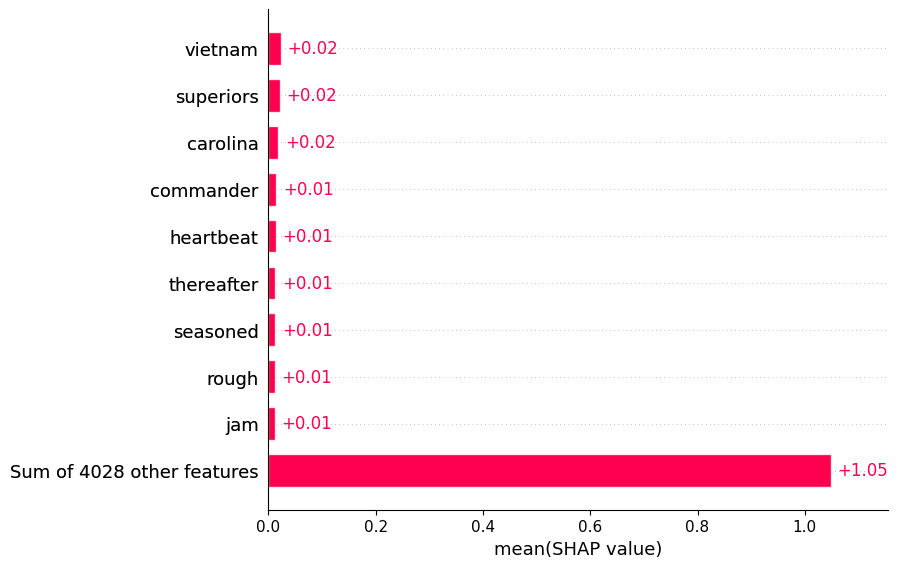

In [233]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort[::-1], max_display=10)

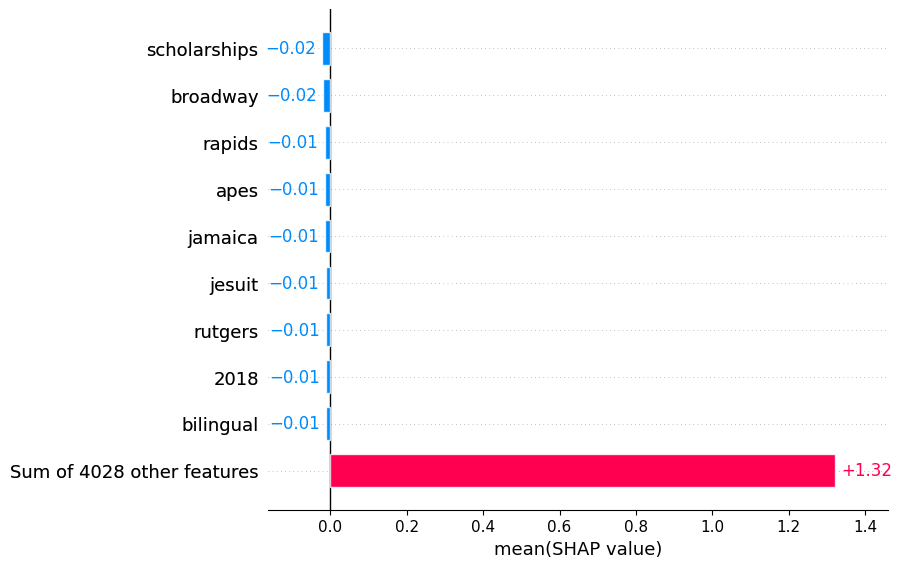

In [234]:
shap.plots.bar(shap_values.mean(0), order=shap.Explanation.argsort, max_display=10)

In [235]:
# shap.plots.bar(shap_values.sum(0), order=shap.Explanation.argsort, max_display=50)

In [198]:
# shap.plots.bar(shap_values.sum(0), order=shap.Explanation.argsort[::-1], max_display=50)

In [150]:
# text = df['s1_s2'][6]

In [152]:
#tokenizer.encode_plus(text, padding="max_length", truncation=True, return_tensors="pt")

In [153]:
# tokenizer.tokenize(text)

['i',
 'had',
 'the',
 'pleasure',
 'of',
 'working',
 'with',
 'doctor',
 'id',
 '##ent',
 '##ifier',
 'in',
 'july',
 'of',
 '2020',
 'when',
 'they',
 'was',
 'a',
 '4',
 '"',
 'year',
 'medical',
 'student',
 'at',
 'the',
 'tour',
 '##o',
 'college',
 'of',
 'os',
 '##te',
 '##opa',
 '##thic',
 'medicine',
 'participating',
 'in',
 'a',
 'id',
 '##ent',
 '##ifier',
 'clerks',
 '##hip',
 'elect',
 '##ive',
 '.',
 'i',
 'found',
 'id',
 '##ent',
 '##ifier',
 'to',
 'be',
 'very',
 'motivated',
 ',',
 'enthusiastic',
 ',',
 'and',
 'a',
 'responsible',
 'and',
 'caring',
 'medical',
 'student',
 '.',
 'they',
 'was',
 'an',
 'active',
 'participant',
 'during',
 'rounds',
 'with',
 'comprehensive',
 ',',
 'well',
 '-',
 'organized',
 'presentations',
 'and',
 'informed',
 'questions',
 '.',
 'they',
 'has',
 'an',
 'excellent',
 'fund',
 'of',
 'medical',
 '/',
 'neurological',
 'knowledge',
 '.']